# TorchSig Workshop: GRCon 2026

09/22/2026

## Install Dependencies

In [1]:
!pip install -q torchsig


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import torchsig
torchsig.__version__

/Users/ereoh/Downloads/GRCon_2026/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'2.2.0'

## Creating a TorchSig Dataset


### 1. Define dataset parameters/metadata using a dict, or use our default values.

In [3]:
# Define Variables
num_signals_max = 5
num_signals_min = 1

In [4]:
from torchsig.utils.defaults import TorchSigDefaults
from pprint import pprint

dataset_metadata = TorchSigDefaults().default_dataset_metadata
dataset_metadata["num_signals_min"] = num_signals_min
dataset_metadata["num_signals_max"] = num_signals_max
pprint(dataset_metadata)

{'bandwidth_max': 3333333,
 'bandwidth_min': 2500000,
 'cochannel_overlap_probability': 0.2,
 'fft_size': 512,
 'fft_stride': 512,
 'frequency_max': 2499999,
 'frequency_min': -2500000,
 'noise_power_db': 0.0,
 'num_iq_samples_dataset': 262144,
 'num_signals_max': 5,
 'num_signals_min': 1,
 'sample_rate': 10000000,
 'signal_center_freq_max': 2499999,
 'signal_center_freq_min': -2500000,
 'signal_duration_in_samples_max': 262144.0,
 'signal_duration_in_samples_min': 209715.2,
 'snr_db_max': 50.0,
 'snr_db_min': 0.0}


### 2. Create a `TorchSigIterableDataset`

The default data returned from datasets are IQ samples.

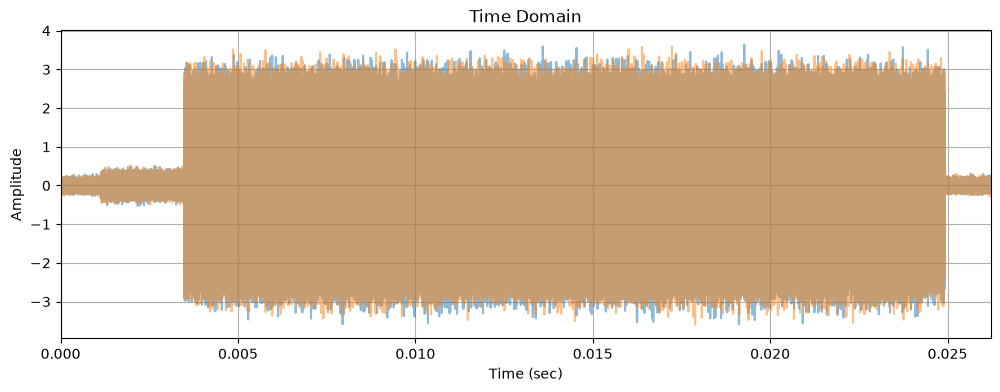

In [5]:
from torchsig.datasets.datasets import TorchSigIterableDataset
from matplotlib import pyplot as plt
import numpy as np

# With target_labels, returns (data, metadata) tuples
dataset_time_series = TorchSigIterableDataset(
    metadata=dataset_metadata, target_labels=["class_index"]
)

data, metadata = next(dataset_time_series)
t = np.arange(0, len(data)) / dataset_time_series.sample_rate

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(t, np.real(data), alpha=0.5, label="Real")
ax.plot(t, np.imag(data), alpha=0.5, label="Imag")
ax.set_xlim([t[0], t[-1]])
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Amplitude")
ax.set_title("Time Domain")
ax.grid()

However, we can change the data using `Transforms` to output spectrogram data.

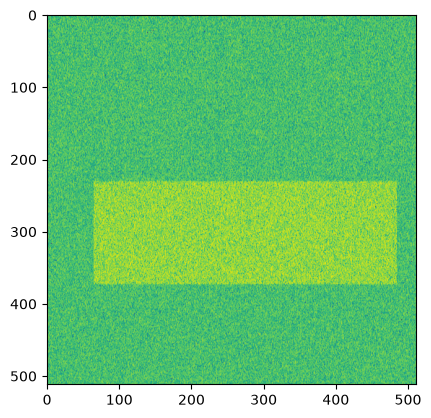

In [6]:
from torchsig.transforms.transforms import Spectrogram

# Without target_labels, returns Signal objects with rich metadata
dataset = TorchSigIterableDataset(
    metadata=dataset_metadata,
    transforms=[Spectrogram(fft_size=dataset_metadata["fft_size"])],
)

plt.imshow(dataset().data)

### 3. Write the Dataset to Disk

In [7]:
from torchsig.utils.writer import DatasetCreator
from torchsig.datasets.datasets import TorchSigIterableDataset
from torchsig.utils.data_loading import WorkerSeedingDataLoader

root = "./datasets/create_dataset_example"
seed = 123456789

In [8]:
# Don't use target_labels to get Signal objects with rich metadata
dataset = TorchSigIterableDataset(
    metadata=dataset_metadata,
    transforms=[Spectrogram(fft_size=dataset_metadata["fft_size"])],
)

dataset_length = 10

dataloader = WorkerSeedingDataLoader(dataset, batch_size=11)
dataloader.seed(seed)

# New simplified DatasetCreator API
dataset_creator = DatasetCreator(
    dataset_length=dataset_length,
    dataloader=dataloader,
    root=root,
    overwrite=True,
    multithreading=False,
)

dataset_creator.create()

Generating Dataset:: 100%|██████████| 1/1 [00:05<00:00,  5.52s/it]


### 4. Read the Dataset from Disk using `StaticTorchSigDataset`

[['8fsk', 'am-usb', 'am-lsb', '4msk', 'ook'],
 [np.float64(0.11328125),
  np.float64(0.006114959716796875),
  np.float64(0.034740447998046875),
  np.float64(0.002811431884765625),
  np.float64(0.020473480224609375)],
 [np.float64(0.9835739135742188),
  np.float64(0.8163032531738281),
  np.float64(0.9256057739257812),
  np.float64(0.9962882995605469),
  np.float64(0.9775352478027344)],
 [np.float64(-2500000.0),
  np.float64(-2500000.0),
  np.float64(-69039.12019152194),
  np.float64(-2500000.0),
  np.float64(719638.4941703142)],
 [np.float64(1040528.2629429466),
  np.float64(-690291.0468165334),
  np.float64(2499999.0),
  np.float64(541337.4567239779),
  np.float64(2499999.0)]]


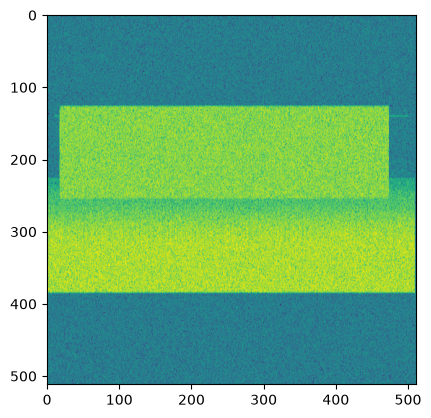

In [9]:
from torchsig.datasets.datasets import StaticTorchSigDataset

static_dataset = StaticTorchSigDataset(
    root=root, target_labels=["class_name", "start", "stop", "lower_freq", "upper_freq"]
)

# can access any sample
data, labels = static_dataset[4]

# can access any sample
pprint(labels)
plt.imshow(data)

## Impairments

In [10]:
from torchsig.transforms.impairments import Impairments

In [11]:
impairments = Impairments(level=2)
burst_impairments = impairments.signal_transforms
whole_signal_impairments = impairments.dataset_transforms

In [12]:
burst_impairments

Compose(transforms=[RandomApply(required_metadata=[],kwargs={},transform=Quantize,probability=0.75), RandomApply(required_metadata=[],kwargs={},transform=ClockDrift,probability=0.75), RandomApply(required_metadata=[],kwargs={},transform=ClockJitter,probability=0.75), RandomApply(required_metadata=[],kwargs={},transform=PassbandRipple,probability=0.75), RandomApply(required_metadata=[],kwargs={},transform=IQImbalance,probability=0.25), RandomApply(required_metadata=[],kwargs={},transform=CarrierPhaseNoise,probability=0.75), RandomApply(required_metadata=[],kwargs={},transform=CarrierFrequencyDrift,probability=0.75), RandomApply(required_metadata=[],kwargs={},transform=CarrierPhaseOffset,probability=1.0), RandomApply(required_metadata=[],kwargs={},transform=IntermodulationProducts,probability=0.5), RandomApply(required_metadata=[],kwargs={},transform=NonlinearAmplifier,probability=0.75), RandomApply(required_metadata=[],kwargs={},transform=SpectralInversion,probability=0.25), RandomApply

In [13]:
whole_signal_impairments

Compose(transforms=[RandAugment(required_metadata=[],kwargs={},transforms=[RandomDropSamples(required_metadata=[],kwargs={},data_dtype=<class 'numpy.complex64'>,precise=False,drop_rate=0.01,size=(1, 1),fill=['ffill', 'bfill', 'mean', 'zero'],drop_rate_distribution=UniformDistribution(params=0.01, seed=8648470692085154492, parent=RandomDropSamples),size_distribution=UniformRangeDistribution(params=(1, 1), seed=8648470692085154492, parent=RandomDropSamples),fill_distribution=ChoiceDistribution(params=['ffill', 'bfill', 'mean', 'zero'], seed=8648470692085154492, parent=RandomDropSamples)), ChannelSwap(required_metadata=[],kwargs={},data_dtype=<class 'numpy.complex64'>,precise=False), TimeReversal(allow_spectral_inversion=1.0,required_metadata=[],kwargs={},data_dtype=<class 'numpy.complex64'>,precise=False), AddSlope(required_metadata=[],kwargs={},data_dtype=<class 'numpy.complex64'>,precise=False)],choose=2,replace=False), RandomApply(required_metadata=[],kwargs={},transform=Intermodulati

In [14]:
dataset_impaired = TorchSigIterableDataset(
    metadata=dataset_metadata,
    transforms=[
        whole_signal_impairments,
        Spectrogram(fft_size=dataset_metadata["fft_size"]),
    ],
    component_transforms=[burst_impairments],
    target_labels=[],
)

dataset_unimpaired = TorchSigIterableDataset(
    metadata=dataset_metadata,
    transforms=[Spectrogram(fft_size=dataset_metadata["fft_size"])],
    component_transforms=[],
    target_labels=[],
)

dataset_impaired.seed(seed)
dataset_unimpaired.seed(seed)

Text(0.5, 1.0, 'Impaired Data')

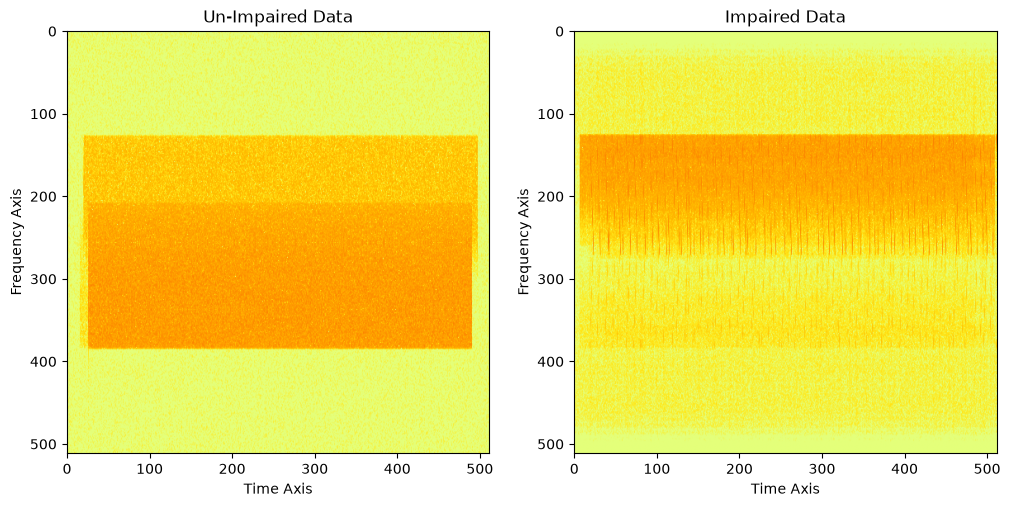

In [15]:
unimpaired_data = next(dataset_unimpaired)
impaired_data = next(dataset_impaired)

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(1, 2, 1)
ax.imshow(unimpaired_data, cmap="Wistia", vmin=0)
ax.set_xlabel("Time Axis")
ax.set_ylabel("Frequency Axis")
ax.set_title("Un-Impaired Data")

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(impaired_data, cmap="Wistia", vmin=0)
ax2.set_xlabel("Time Axis")
ax2.set_ylabel("Frequency Axis")
ax2.set_title("Impaired Data")
